<a href="https://colab.research.google.com/github/Mithu06-dev/AIML-Learning-/blob/main/Linear%20Regression%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

       GENERATED TITANIC DATASET

First 10 Rows:
   Pclass  Sex  Age  SibSp  Parch    Fare  Survived
0       2    0   72      1      1  163.29         0
1       3    1   31      1      2  127.34         1
2       3    0    9      4      1   70.17         0
3       3    1   51      3      1   41.56         0
4       1    0   29      4      1   36.16         0
5       1    1   78      3      0  216.84         1
6       1    0   40      4      1   64.65         0
7       3    0   41      4      0  164.67         0
8       3    1   11      0      3  203.62         1
9       3    0   23      1      2  155.45         0

Dataset Shape:
(400, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    400 non-null    int64  
 1   Sex       400 non-null    int64  
 2   Age       400 non-null    int64  
 3   SibSp     400 non-null    in

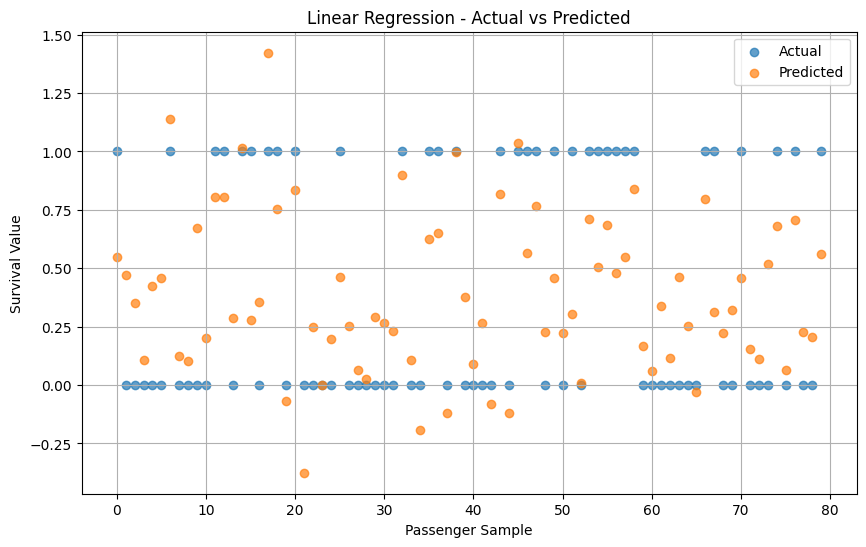

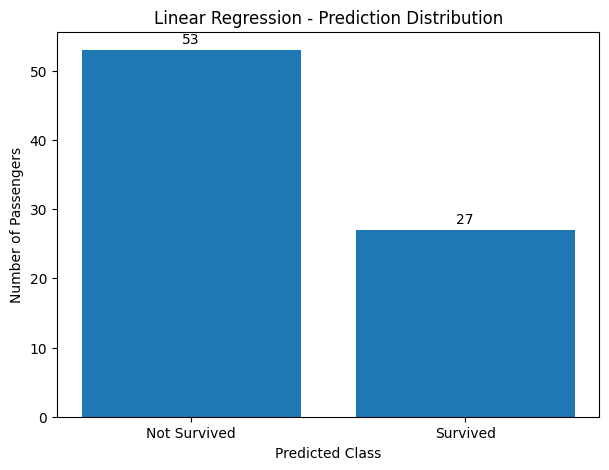

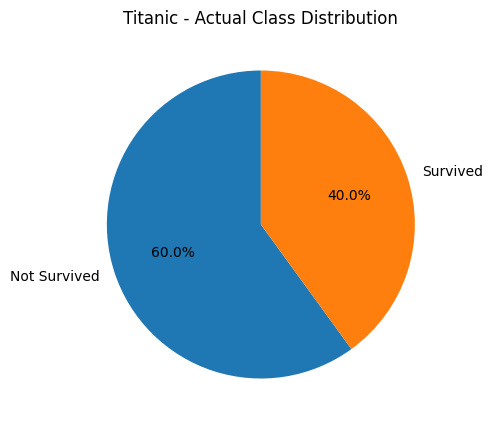


           FINAL RESULT
Linear Regression Accuracy = 88.75%
R² Score = 0.5718
RMSE = 0.3206

Graphs Generated:
1. Actual vs Predicted
2. Prediction Distribution
3. Actual Class Distribution


In [10]:
# ============================================================
# LINEAR REGRESSION - TITANIC DATASET
# DATASET GENERATED INSIDE THE CODE
# ============================================================

# ------------------------------------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# 2. GENERATE TITANIC-STYLE DATASET
# ------------------------------------------------------------

np.random.seed(42)

n = 400

# Passenger class
Pclass = np.random.choice(
    [1, 2, 3],
    size=n,
    p=[0.25, 0.25, 0.50]
)

# Sex
Sex = np.random.choice(
    [0, 1],
    size=n,
    p=[0.65, 0.35]
)

# Age
Age = np.random.randint(
    1,
    80,
    size=n
)

# Number of siblings/spouses
SibSp = np.random.randint(
    0,
    5,
    size=n
)

# Number of parents/children
Parch = np.random.randint(
    0,
    5,
    size=n
)

# Fare
Fare = np.round(
    np.random.uniform(
        5,
        250,
        size=n
    ),
    2
)


# ------------------------------------------------------------
# 3. CREATE SURVIVAL TARGET
# ------------------------------------------------------------

# Create survival probability
survival_score = (
    0.35
    + 0.20 * Sex
    + 0.15 * (Pclass == 1)
    + 0.08 * (Pclass == 2)
    - 0.003 * Age
    - 0.02 * SibSp
    + 0.001 * Fare
)

# Add random noise
survival_score += np.random.normal(
    0,
    0.10,
    n
)

# Convert probability into 0/1
Survived = (
    survival_score > 0.50
).astype(int)


# ------------------------------------------------------------
# 4. CREATE DATAFRAME
# ------------------------------------------------------------

df = pd.DataFrame({
    "Pclass": Pclass,
    "Sex": Sex,
    "Age": Age,
    "SibSp": SibSp,
    "Parch": Parch,
    "Fare": Fare,
    "Survived": Survived
})


# ------------------------------------------------------------
# 5. DISPLAY DATASET
# ------------------------------------------------------------

print("======================================")
print("       GENERATED TITANIC DATASET")
print("======================================")

print("\nFirst 10 Rows:")
print(df.head(10))

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nSurvival Distribution:")
print(df["Survived"].value_counts())


# ------------------------------------------------------------
# 6. SEPARATE FEATURES AND TARGET
# ------------------------------------------------------------

X = df.drop(
    "Survived",
    axis=1
)

y = df["Survived"]


# ------------------------------------------------------------
# 7. TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)


# ------------------------------------------------------------
# 8. CREATE LINEAR REGRESSION MODEL
# ------------------------------------------------------------

model = LinearRegression()


# ------------------------------------------------------------
# 9. TRAIN MODEL
# ------------------------------------------------------------

model.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 10. PREDICTION
# ------------------------------------------------------------

y_pred = model.predict(
    X_test
)


# ------------------------------------------------------------
# 11. CONVERT PREDICTIONS TO CLASS
# ------------------------------------------------------------

# >= 0.5 = Survived
# < 0.5 = Not Survived

y_pred_class = (
    y_pred >= 0.5
).astype(int)


# ------------------------------------------------------------
# 12. CALCULATE ACCURACY
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_test,
    y_pred_class
)


# ------------------------------------------------------------
# 13. CALCULATE R2 SCORE
# ------------------------------------------------------------

r2 = r2_score(
    y_test,
    y_pred
)


# ------------------------------------------------------------
# 14. CALCULATE RMSE
# ------------------------------------------------------------

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)


# ------------------------------------------------------------
# 15. DISPLAY RESULTS
# ------------------------------------------------------------

print("\n======================================")
print("     LINEAR REGRESSION RESULTS")
print("======================================")

print(
    f"Accuracy = {accuracy:.4f}"
)

print(
    f"Accuracy Percentage = {accuracy * 100:.2f}%"
)

print(
    f"R² Score = {r2:.4f}"
)

print(
    f"RMSE = {rmse:.4f}"
)


# ============================================================
# GRAPH 1 - ACTUAL VS PREDICTED
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    range(len(y_test)),
    y_test,
    label="Actual",
    alpha=0.7
)

plt.scatter(
    range(len(y_pred)),
    y_pred,
    label="Predicted",
    alpha=0.7
)

plt.xlabel(
    "Passenger Sample"
)

plt.ylabel(
    "Survival Value"
)

plt.title(
    "Linear Regression - Actual vs Predicted"
)

plt.legend()

plt.grid(True)

plt.show()


# ============================================================
# GRAPH 2 - PREDICTION DISTRIBUTION
# ============================================================

prediction_counts = pd.Series(
    y_pred_class
).value_counts().reindex(
    [0, 1],
    fill_value=0
)


plt.figure(
    figsize=(7, 5)
)

plt.bar(
    ["Not Survived", "Survived"],
    prediction_counts.values
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Number of Passengers"
)

plt.title(
    "Linear Regression - Prediction Distribution"
)


# Add values
for i, value in enumerate(
    prediction_counts.values
):

    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )

plt.show()


# ============================================================
# GRAPH 3 - ACTUAL CLASS DISTRIBUTION
# ============================================================

actual_counts = pd.Series(
    y_test
).value_counts().reindex(
    [0, 1],
    fill_value=0
)


plt.figure(
    figsize=(7, 5)
)

plt.pie(
    actual_counts.values,

    labels=[
        "Not Survived",
        "Survived"
    ],

    autopct="%1.1f%%",

    startangle=90
)

plt.title(
    "Titanic - Actual Class Distribution"
)

plt.show()


# ============================================================
# FINAL RESULT
# ============================================================

print("\n======================================")
print("           FINAL RESULT")
print("======================================")

print(
    f"Linear Regression Accuracy = "
    f"{accuracy * 100:.2f}%"
)

print(
    f"R² Score = {r2:.4f}"
)

print(
    f"RMSE = {rmse:.4f}"
)

print("\nGraphs Generated:")
print("1. Actual vs Predicted")
print("2. Prediction Distribution")
print("3. Actual Class Distribution")